In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Olist'in Tahmini Teslimat Süresini (ETA) İyileştirme

👉 `Estimated Time of Arrival (ETA)`, modern e-ticaret hizmetlerinin temel bileşenlerinden biridir. Şirketlerin müşteriye teslimat için tahmini bir tarih göstererek beklentileri yönetmesini sağlar.

🎯 Bu çalışmada, bir siparişin `bekleme süresini tahmin eden` bir model kuracağız.

☑️ Olist'in kendi tahminleri `expected_wait_time` değişkeninde zaten mevcut.

🚀 Hadi daha iyi tahminler yapmaya çalışalım ve bu özetin sonunda şunları karşılaştıralım:
* bizim `estimated_wait_time`
* Olist'in `expected_wait_time`
* teslim edilen her sipariş için gerçek `wait_time`

## `orders` veri setini yükle ve kontrol et

👉 `Order().get_training_data()` (`distance_seller_customer` dahil)

In [2]:
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)

In [3]:
orders.head(3)

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,dim_is_five_star,dim_is_one_star,review_score,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered,0,0,4,1,1,29.99,8.72,18.063837
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered,0,0,4,1,1,118.70,22.76,856.292580
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered,1,0,5,1,1,159.90,19.22,514.130333


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95872 entries, 0 to 95879
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  95872 non-null  object 
 1   wait_time                 95872 non-null  float64
 2   expected_wait_time        95872 non-null  float64
 3   delay_vs_expected         95872 non-null  float64
 4   order_status              95872 non-null  object 
 5   dim_is_five_star          95872 non-null  int64  
 6   dim_is_one_star           95872 non-null  int64  
 7   review_score              95872 non-null  int64  
 8   number_of_items           95872 non-null  int64  
 9   number_of_sellers         95872 non-null  int64  
 10  price                     95872 non-null  float64
 11  freight_value             95872 non-null  float64
 12  distance_seller_customer  95872 non-null  float64
dtypes: float64(6), int64(5), object(2)
memory usage: 10.2+ MB


## Temel Model - Olist'in mevcut ETA modeli

🐣  Optimize etmek istediğimiz temel seviye (baseline) nedir ❓

👉 Olist'in `expected_wait_time` değeri ile gerçek `wait_time` arasındaki fark

📈 İlgili histogramlarını çiz

In [5]:
orders["baseline_error"]= orders["expected_wait_time"] - orders["wait_time"]

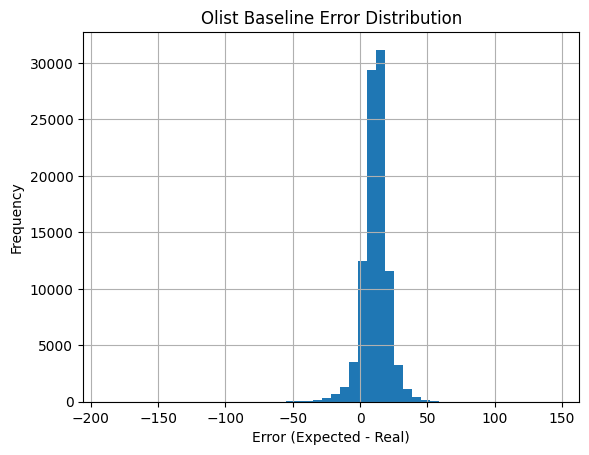

In [7]:
import matplotlib.pyplot as plt

orders["baseline_error"].hist(bins=50)
plt.title("Olist Baseline Error Distribution")
plt.xlabel("Error (Expected - Real)")
plt.ylabel("Frequency")
plt.show()

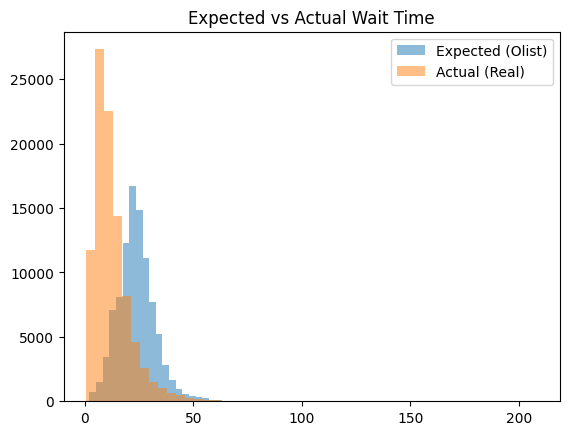

In [9]:
plt.hist(orders["expected_wait_time"], bins=50, alpha=0.5, label="Expected (Olist)")
plt.hist(orders["wait_time"], bins=50, alpha=0.5, label="Actual (Real)")

plt.legend()
plt.title("Expected vs Actual Wait Time")
plt.show()

In [11]:
orders["baseline_error"].mean()

11.22561699791466

👉 Medyan bekleme süresi nedir? Medyan beklenen bekleme süresi nedir?

In [13]:
orders["wait_time"].median()

10.203726851851851

👉 Temel RMSE'yi hesapla

ℹ️ Burada ele alınan hatalar, Olist'in bekleme süresi tahminindeki sapmalarıdır.

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_true = orders["wait_time"]
y_pred = orders["expected_wait_time"]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(rmse)

15.110701386210625


## OLS çok değişkenli model

👉 Bu sefer `statsmodel.api.OLS` yöntemini kullanarak bir OLS modeli oluşturacağız.

(`statsmodel.formula.api.ols` yerine)

### X özellikleri ve Y hedefi ile veri setini hazırla

In [16]:
import statsmodels.api as sm

y = orders["wait_time"]

X = orders[[
    "order_status",
    "dim_is_five_star",
    "dim_is_one_star",
    "review_score",
    "number_of_items",
    "number_of_sellers",
    "price",
    "freight_value",
    "distance_seller_customer"
]]

⚖️ OLS sonucunda elde edilecek regresyon katsayılarını karşılaştırabilmek için X'in her bir özelliğini standartlaştır (`z-score`):

In [17]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

features = [
    "dim_is_five_star",
    "dim_is_one_star",
    "review_score",
    "number_of_items",
    "number_of_sellers",
    "price",
    "freight_value",
    "distance_seller_customer"
]

X = orders[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)

In [18]:
# Check how different is it from the "formula" in statsmodel
import patsy
patsy.dmatrix('price + distance_seller_customer', orders)

DesignMatrix with shape (95872, 3)
  Intercept   price  distance_seller_customer
          1   29.99                  18.06384
          1  118.70                 856.29258
          1  159.90                 514.13033
          1   45.00                1822.80037
          1   19.90                  30.17404
          1  147.90                 411.95300
          1   59.99                 321.73040
          1   19.90                 872.66930
          1  149.99                 111.51773
          1  198.00                 413.25219
          1   98.00                 844.97722
          1   31.90                 452.20571
          1   19.90                 308.45551
          1   38.25                 430.59899
          1  132.40                 161.60460
          1   27.99                 547.73905
          1   17.90                 209.39770
          1   76.00                1434.17366
          1  109.90                  11.84639
          1   79.99                  19.27366

⚠️ Bu `statsmodel.api.OLS` ile, özellikler veri setine her zaman sabit bir "intercept" (kesme) eklememiz gerekir:

In [19]:
import statsmodels.api as sm

X = sm.add_constant(X)  # intercept ekler
model = sm.OLS(y, X).fit()

### `statsmodels` ile OLS'i çalıştır ve `summary` çıktısını yazdır

In [20]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              wait_time   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     4365.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:17:47   Log-Likelihood:            -3.3653e+05
No. Observations:               95872   AIC:                         6.731e+05
Df Residuals:                   95863   BIC:                         6.732e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## OLS modelinin performansını kontrol et

### Uyum iyiliği (goodness of fit)

👉 En iyi tahminleri kim yapıyor: sen mi, Olist mi?

- Tahminlerini hesapla ve `y_pred` değişkeninde sakla

- Şunları da saklayabilirsin:
    - Olist'in tahminlerini `y_expected_olist` değişkeninde
    - gerçek bekleme sürelerini `y_true` değişkeninde


In [21]:
y_pred = model.predict(X)

In [22]:
y_true = orders["wait_time"]

In [23]:
y_expected_olist = orders["expected_wait_time"]

📈 `y_pred`, `y_expected_olist` ve `y_true` değerlerini aynı grafikte çiz.

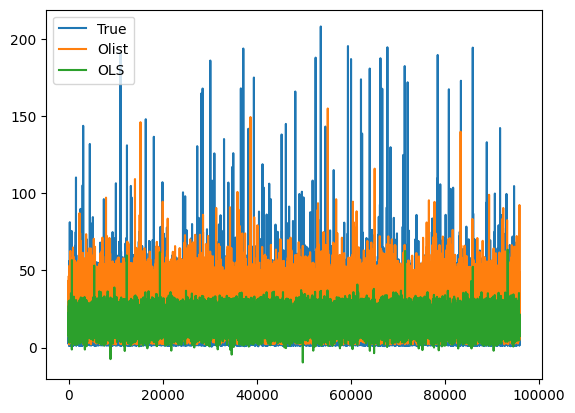

In [24]:
import matplotlib.pyplot as plt

plt.plot(y_true, label="True")
plt.plot(y_expected_olist, label="Olist")
plt.plot(y_pred, label="OLS")

plt.legend()
plt.show()

👉 Artık hatalar *senin* hataların olacak şekilde RMSE'yi hesapla!

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_model = np.sqrt(mean_squared_error(y_true, y_pred))
print(rmse_model)

8.094831005355763


Hatırlatma olarak, Olist'in RMSE'si şuna eşitti: 👇

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_rmse = np.sqrt(
    mean_squared_error(y_true, y_expected_olist)
)

print(baseline_rmse)

15.110701386210625


😏 Gerçekten Olist'in Veri Bilimcilerini yendik mi? Pek de öyle diyemeyiz!

- Birçok e-ticaret ve teslimat servisinde ETA çoğu zaman yüksek tahmin edilir...
- Müşteriler siparişlerini beklenenden erken aldıklarında memnun olma olasılıkları daha yüksektir!

### Kısmi korelasyonlar

👉 `sm.graphics.plot_partregress_grid` ile kısmi korelasyonları görselleştir

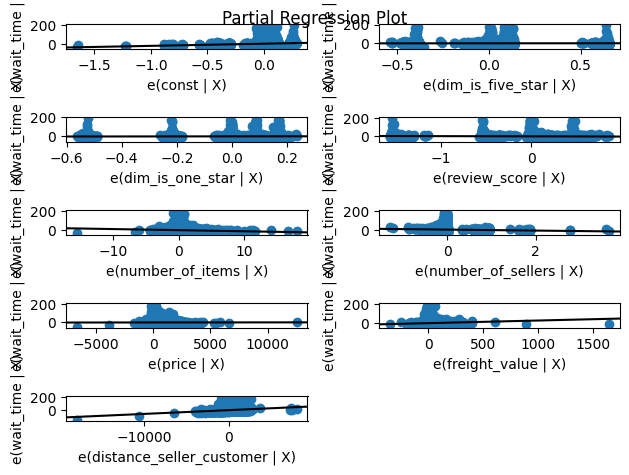

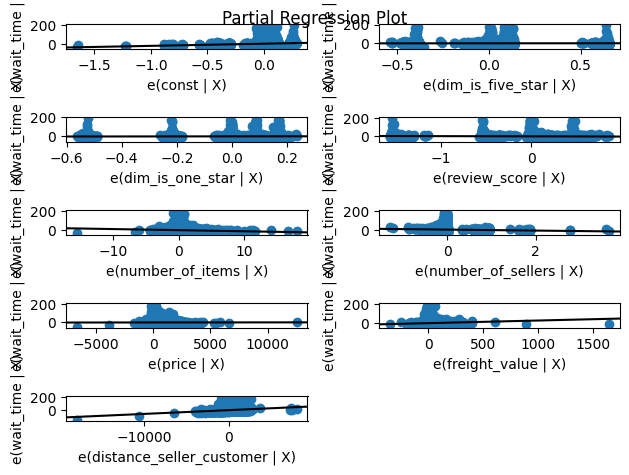

In [28]:
import statsmodels.api as sm

sm.graphics.plot_partregress_grid(model)

**Bu grafikleri nasıl okuruz?**

👉 Örneğin sol alt köşedeki grafiğe odaklanalım:

<u>`wait_time` ile `distance` arasındaki kısmi regresyon</u>

- Her nokta veri setimizdeki bir sipariştir


- `y-ekseni`: `distance` hariç tüm özellikleri kullanarak elde edilen `wait_time` artık (residual) değerleri

    - Bu artıklar, `distance` olmadan açıklanamayan `wait_time` hakkındaki kalan bilgiyi içerir


- `x-ekseni`: diğer tüm özellikler (price, freight_value, vb...) kullanılarak `distance` tahmininin artık (residual) değerleri
    - Bu artıklar, modeldeki diğer özelliklerle zaten açıklanmayan ve `distance` değişkeninin getirdiği yeni bilgiyi içerir.


### Çıkarımsal koşullar

⚠️ Artık (residual) değerlerini kontrol et. Normal dağılıma uyuyorlar mı?

In [29]:
residuals = y_true - y_pred

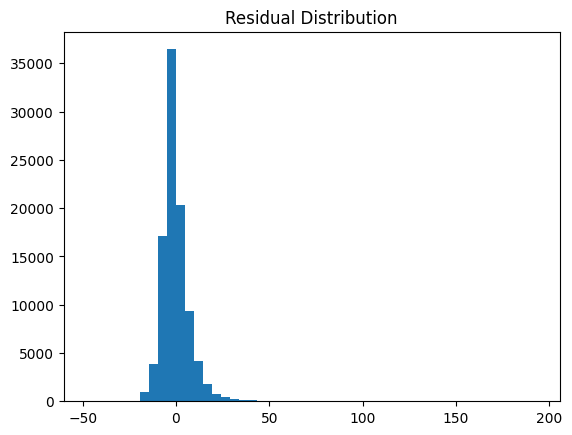

In [30]:
import matplotlib.pyplot as plt

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

🎁 Bir dağılımın Gauss (normal) olup olmadığını daha hassas görselleştirmenin bir yolu <a href="https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html">**`QQplot`**</a>'tur.

📈 Aşağıya artık (residual) değerlerinin QQplot'unu çiz.

💡 QQ plot ile az önce çizilen yoğunluk (density) grafiği arasındaki ilişkiyi mutlaka anla..

📚 <a href="https://stats.stackexchange.com/questions/101274/how-to-interpret-a-qq-plot">Stats.StackExchange.com - QQplot yorumlama</a>

- `x-axis` : bir Gauss dağılımının teorik kantilleri
- `y-axis`: sıralanmış değişkenin kantilleri

💡 Eğer <span style="color:blue">mavi</span> noktalar, özdeşlik (identity) fonksiyonu olan <span style="color:red">kırmızı çizgi</span> üzerinde hizalanıyorsa, değişken Gauss dağılımına sahiptir!

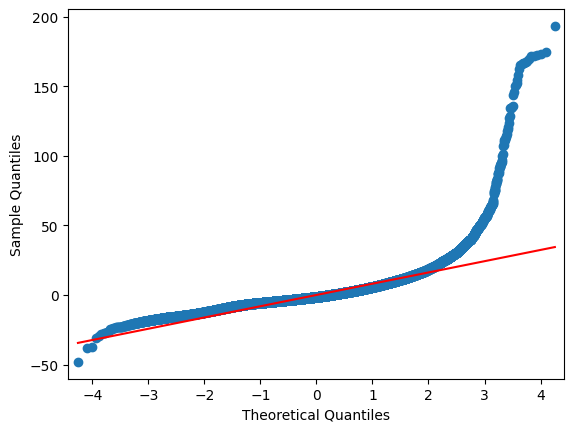

In [32]:
sm.qqplot(residuals, line='s');

#### Bazı QQplot örnekleri:

QQ plot'ların nasıl çizildiğini anlamak için aşağıdaki hücreleri çalıştır:

In [33]:
from scipy import stats
stats.norm.rvs(0,1)

1.3318770104188427

(-4.536117558608352, 10.0)

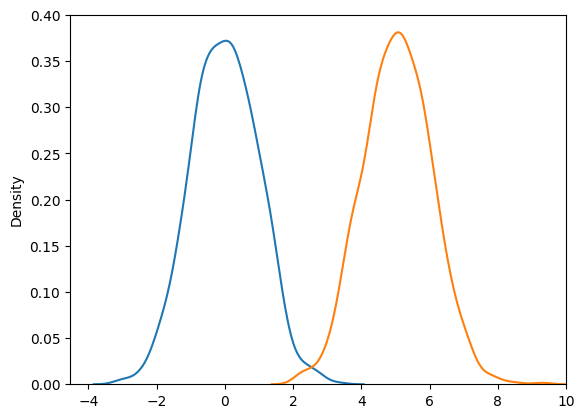

In [34]:
# lets check QQ plots with our own distributions
from scipy import stats

norm_1 = [stats.norm.rvs(0,1) for x in range(1000)]
norm_2 = [stats.norm.rvs(5,1) for x in range(1000)]

sns.kdeplot(norm_1)
sns.kdeplot(norm_2)
plt.xlim(right=10)

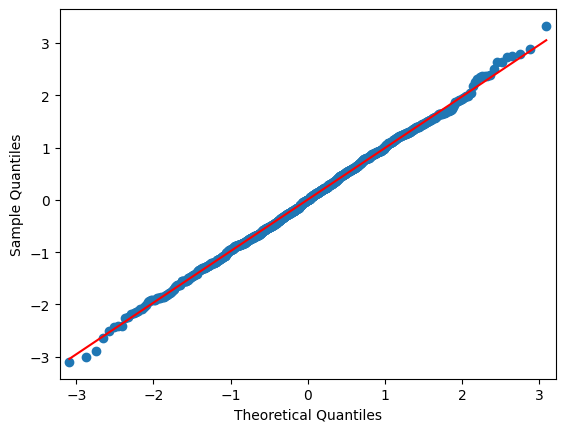

In [35]:
sm.qqplot(np.asarray(norm_1), line='s');

(-5.677523810002976, 10.0)

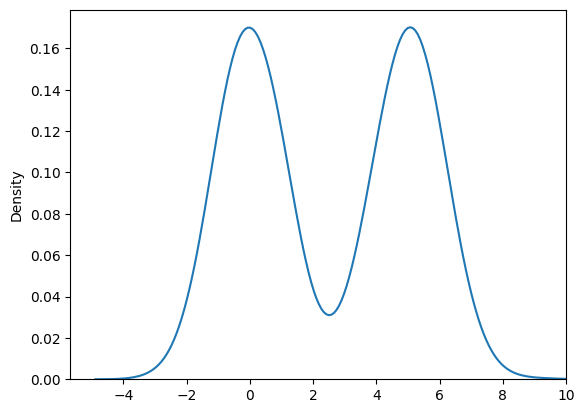

In [36]:
bimodal = norm_1 + norm_2
sns.kdeplot(bimodal)
plt.xlim(right=10)

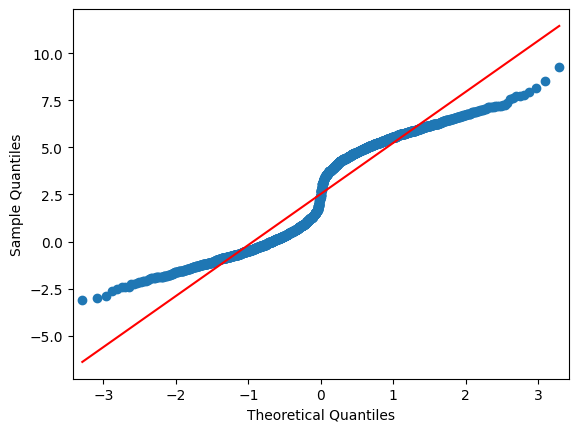

In [37]:
sm.qqplot(np.asarray(bimodal), line='s');

<img src="https://wagon-public-datasets.s3.amazonaws.com/04-Decision-Science/03-Linear-Regression/qq_plot_interpretation.png" width=400>

#### Rastgele olmayan bir desen yakalayıp yakalayamayacağımızı görmek için artıklar (residuals) vs. uyumlanan (fitted) değerleri kontrol et

(0.0, 50.0)

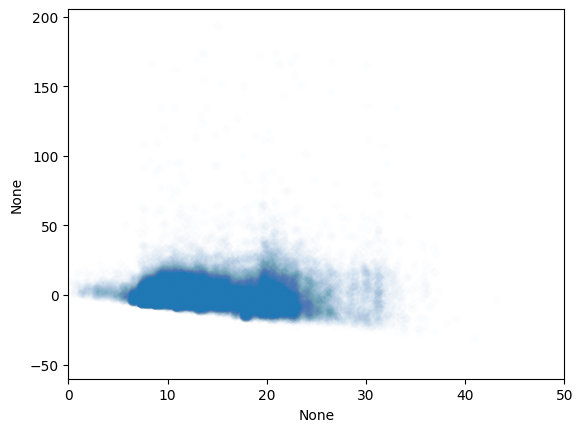

In [39]:
sns.scatterplot(x = y_pred, y = residuals, alpha=0.01)
plt.xlim(xmin=0, xmax=50)

## Daha Fazla Özellik? (Opsiyonel)

Burada ürün detaylarından (boyut, kategori vb.) ek özellikler ekleyebiliriz.

### Her siparişle ilişkili ürün detaylarını ekle (ürün boyutları toplamı, ağırlıklar toplamı vb.)

In [40]:
from olist.data import Olist
data = Olist().get_data()
products = data['products']
order_items = data['order_items']

In [41]:
order_items_products = (
    order_items.groupby(["order_id", "product_id"], as_index=False)
    .agg({"order_item_id": "count"})
    .rename(columns={"order_item_id": "order_item_count"})
    .merge(products.drop(["product_category_name"], axis=1), on="product_id")
)
order_items_products

,order_id,product_id,order_item_count,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,1,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,1,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...
102420,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,1,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
102421,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,1,31.0,232.0,1.0,8950.0,45.0,26.0,38.0
102422,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,1,43.0,869.0,1.0,967.0,21.0,24.0,19.0
102423,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,1,56.0,1306.0,1.0,100.0,20.0,20.0,20.0


In [42]:
# Since we want the sum of product weights per order from our new DataFrame, we need to multiply weight by product count
order_items_products['product_weight_g'] = order_items_products['product_weight_g'] *  order_items_products['order_item_count']

order_items_features = order_items_products.groupby("order_id", as_index=False).agg(
    {
        "product_weight_g": "sum",
        "product_length_cm": "max",
        "product_height_cm": "max",
        "product_width_cm": "max",
    }).rename(columns={
        "product_weight_g": "product_weight_g_sum",
        "product_length_cm": "product_length_cm_max",
        "product_height_cm": "product_height_cm_max",
        "product_width_cm": "product_width_cm_max",
    })
order_items_features

,order_id,product_weight_g_sum,product_length_cm_max,product_height_cm_max,product_width_cm_max
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,35.0,40.0,30.0
...,...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,10150.0,89.0,15.0,40.0
98662,fffcd46ef2263f404302a634eb57f7eb,8950.0,45.0,26.0,38.0
98663,fffce4705a9662cd70adb13d4a31832d,967.0,21.0,24.0,19.0
98664,fffe18544ffabc95dfada21779c9644f,100.0,20.0,20.0,20.0


In [43]:
orders_with_details = orders.merge(order_items_features, on="order_id", how="left").dropna()

In [44]:
X2 = orders_with_details[[
        "number_of_items",
        "number_of_sellers",
        "price",
        "freight_value",
        "distance_seller_customer",
        "product_weight_g_sum",
        "product_length_cm_max",
        "product_height_cm_max",
        "product_width_cm_max"]].copy()
y2 = orders_with_details["wait_time"].copy()

In [45]:
# standardize (z-normalize) each features of X to compare coefficients
for f in X2.columns:
    mu = X2[f].mean()
    sigma = X2[f].std()
    X2[f] = X2[f].map(lambda x: (x - mu) / sigma)

In [46]:
X2['constant'] = 1

In [47]:
model2 = sm.OLS(y2, X2).fit()

In [48]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              wait_time   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     2112.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:01:55   Log-Likelihood:            -3.4269e+05
No. Observations:               95856   AIC:                         6.854e+05
Df Residuals:                   95846   BIC:                         6.855e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
number_of_items             -0.1747      0.033     -5.232      0.000      -0.240      -0.109
number_of_sellers           -0.3686      0.029    -12.600      0.000      -0.426      -0.311
price                       -0.0249      0.031     -0.805      0.421      -0.085       0.036
freight_value                0.0912      0.046      1.994      0.046       0.002       0.181
distance_seller_customer     3.7073      0.031    117.856      0.000       3.646       3.769
product_weight_g_sum         0.4430      0.045      9.860      0.000       0.355       0.531
product_length_cm_max        0.4018      0.034     11.661      0.000       0.334       0.469
product_height_cm_max        0.2364      0.033      7.061      0.000       0.171       0.302
product_width_cm_max        -0.0428      0.035     -1.213      0.225      -0.112       0.026
constant                    12.5135      0.028    448.526      0.000      12.459      12.568
==============================================================================
Omnibus:                    91611.645   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         10185560.909
Skew:                           4.340   Prob(JB):                         0.00
Kurtosis:                      52.748   Cond. No.                         3.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""